# Importing required libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
import torchvision
import os
torch.manual_seed(42)

# Dataset preprocessing


In [ ]:

# Define transformations
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load CIFAR-100 dataset
full_trainset = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

# Get labels for one-hot encoding later
train_labels = torch.tensor(full_trainset.targets)
test_labels = torch.tensor(testset.targets)

# Loop over different train-validation splits
split_ratios = [0.7, 0.8, 0.9]  # 70-30, 80-20, 90-10 train-validation splits
batch_size = 128
num_classes = 100  # CIFAR-100 has 100 classes

for split in split_ratios:
    train_size = int(split * len(full_trainset))   # Compute train size
    valid_size = len(full_trainset) - train_size  # Compute validation size

    # Perform split
    trainset, validset = random_split(full_trainset, [train_size, valid_size])

    # Extract labels for train and valid splits
    train_labels_split = train_labels[:train_size]
    valid_labels_split = train_labels[train_size:]

    # Convert labels to one-hot encoding
    y_train_onehot = F.one_hot(train_labels_split, num_classes=num_classes).float()
    y_valid_onehot = F.one_hot(valid_labels_split, num_classes=num_classes).float()
    y_test_onehot = F.one_hot(test_labels, num_classes=num_classes).float()

    # Create dataloaders
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    validloader = DataLoader(validset, batch_size=batch_size, shuffle=False, num_workers=2)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Print dataset sizes for the current split
    print(f"Split {split * 100:.0f}-{(1 - split) * 100:.0f}:")
    print(f"  Train samples: {len(trainset)}, One-hot shape: {y_train_onehot.shape}")
    print(f"  Validation samples: {len(validset)}, One-hot shape: {y_valid_onehot.shape}")
    print(f"  Test samples: {len(testset)}, One-hot shape: {y_test_onehot.shape}")
    print("=" * 40)


100%|██████████| 169M/169M [00:02<00:00, 63.7MB/s] 


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified
Split 70-30:
  Train samples: 35000, One-hot shape: torch.Size([35000, 100])
  Validation samples: 15000, One-hot shape: torch.Size([15000, 100])
  Test samples: 10000, One-hot shape: torch.Size([10000, 100])
Split 80-20:
  Train samples: 40000, One-hot shape: torch.Size([40000, 100])
  Validation samples: 10000, One-hot shape: torch.Size([10000, 100])
  Test samples: 10000, One-hot shape: torch.Size([10000, 100])
Split 90-10:
  Train samples: 45000, One-hot shape: torch.Size([45000, 100])
  Validation samples: 5000, One-hot shape: torch.Size([5000, 100])
  Test samples: 10000, One-hot shape: torch.Size([10000, 100])


Display some images

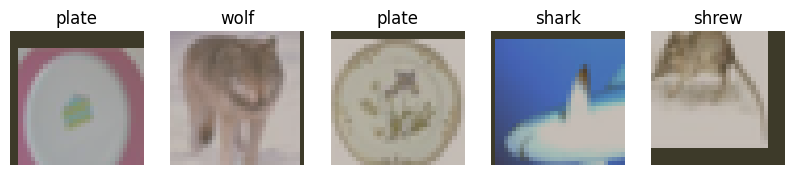

In [ ]:
# Function to display images
def show_images(images, labels, class_names, num=5):
    fig, axes = plt.subplots(1, num, figsize=(10, 5))
    for i in range(num):
        ax = axes[i]
        img = images[i].numpy().transpose((1, 2, 0))  # Convert to HWC format
        img = img * np.array([0.2675, 0.2565, 0.2761]) + np.array([0.5071, 0.4867, 0.4408])  # Denormalize
        img = np.clip(img, 0, 1)  # Clip values for display
        ax.imshow(img)
        ax.set_title(class_names[labels[i]])
        ax.axis("off")
    plt.show()

# Get class names
class_names = full_trainset.classes

# Get a batch of training data
data_iter = iter(trainloader)
images, labels = next(data_iter)

# Show sample images
show_images(images[:5], labels[:5], class_names)


Mapping

In [ ]:
fine_to_superclass = {idx: (idx // 5) for idx in range(100)}  # Superclass (0-19)
superclass_to_group = {
    0: 3, 1: 3,  # Aquatic animals
    2: 0, 17: 0, 4: 0,  # Plants/Parts of plants
    18: 1, 19: 1,  # Vehicles
    13: 2, 7: 2,  # Invertebrates
    8: 4, 11: 4,  # Large animals
    3: 5, 5: 5, 6: 5, 9: 5,  # Man-made articles
    14: 6,  # People
    15: 7, 12: 7, 16: 7,  # Normal terrestrial animals
    10: 8  # Outdoor scenes
}



# Custom CNN model with multiple classifier heads

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # 32 filters
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 64 filters
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1) # 128 filters
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)  # Adjusted input
        self.fc2 = nn.Linear(512, 100)  # Shared dense layer

        self.fc_fine = nn.Linear(100, 100)
        self.fc_super = nn.Linear(100, 20)
        self.fc_group = nn.Linear(100, 9)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x1 = self.fc_fine(x)
        x2 = self.fc_super(x)
        x3 = self.fc_group(x)

        return x1, x2, x3

## Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define hyperparameters
num_epochs = 30
batch_size = 128
learning_rate = 0.001
early_stopping_patience = 3
splits = [0.7, 0.8, 0.9]  # Different train-validation splits

# Define loss function
criterion = nn.CrossEntropyLoss()


🔹 Training with 70:30 split 🔹


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 2.7542, Val Loss: 2.6117
✔ Model saved at epoch 1 for split 70
Epoch 2/30 - Train Loss: 2.5207, Val Loss: 2.4844
✔ Model saved at epoch 2 for split 70
Epoch 3/30 - Train Loss: 2.3675, Val Loss: 2.3034
✔ Model saved at epoch 3 for split 70
Epoch 4/30 - Train Loss: 2.2415, Val Loss: 2.2064
✔ Model saved at epoch 4 for split 70
Epoch 5/30 - Train Loss: 2.1362, Val Loss: 2.1476
✔ Model saved at epoch 5 for split 70
Epoch 6/30 - Train Loss: 2.0500, Val Loss: 2.0743
✔ Model saved at epoch 6 for split 70
Epoch 7/30 - Train Loss: 1.9789, Val Loss: 2.0289
✔ Model saved at epoch 7 for split 70
Epoch 8/30 - Train Loss: 1.9219, Val Loss: 2.0269
✔ Model saved at epoch 8 for split 70
Epoch 9/30 - Train Loss: 1.8686, Val Loss: 1.9668
✔ Model saved at epoch 9 for split 70
Epoch 10/30 - Train Loss: 1.8217, Val Loss: 1.9440
✔ Model saved at epoch 10 for split 70
Epoch 11/30 - Train Loss: 1.7734, Val Loss: 1.8843
✔ Model saved at epoch 11 for split 70
Epoch 12/30 - Train Loss: 1.

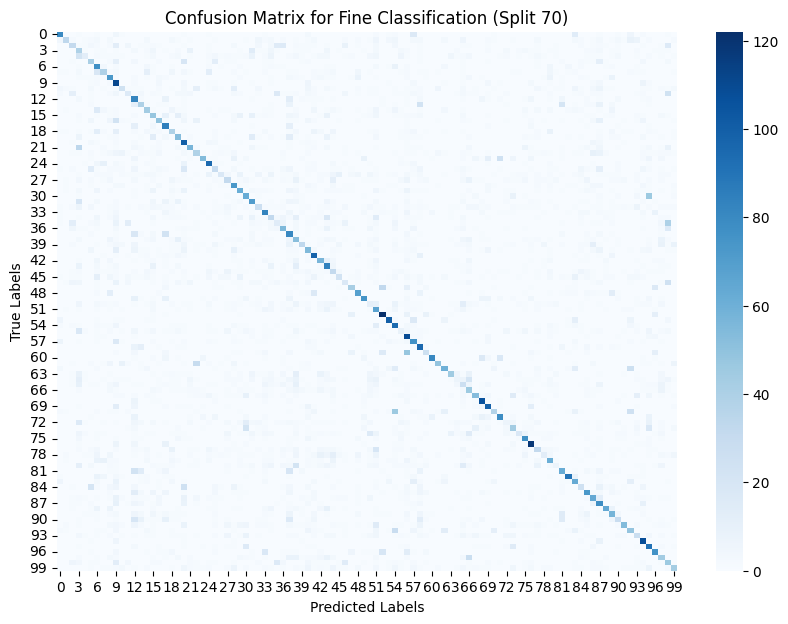

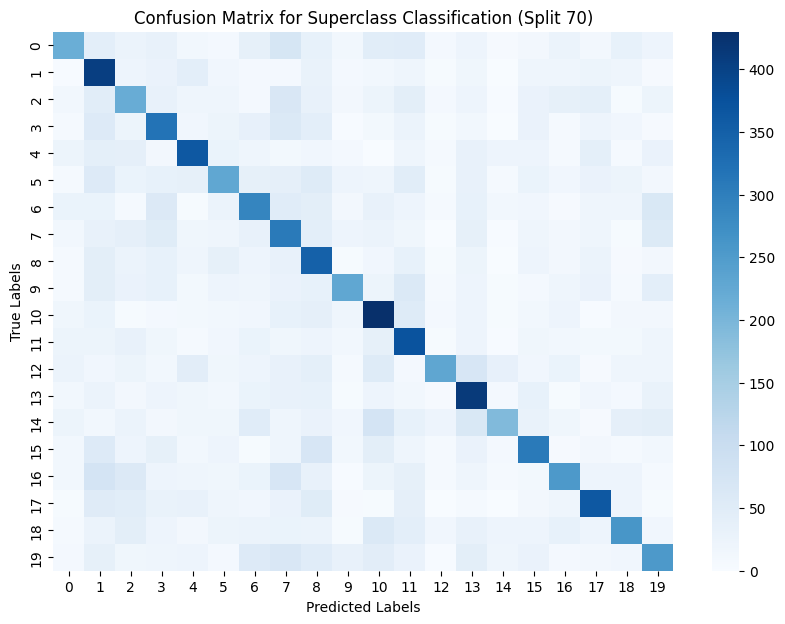

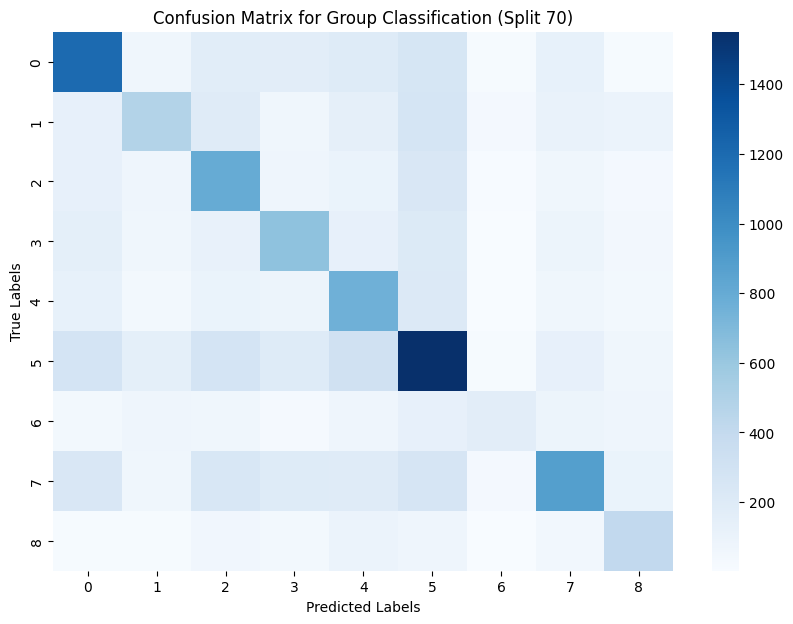


🔹 Training with 80:19 split 🔹


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 2.7490, Val Loss: 2.6042
✔ Model saved at epoch 1 for split 80
Epoch 2/30 - Train Loss: 2.5009, Val Loss: 2.4820
✔ Model saved at epoch 2 for split 80
Epoch 3/30 - Train Loss: 2.3576, Val Loss: 2.3458
✔ Model saved at epoch 3 for split 80
Epoch 4/30 - Train Loss: 2.2397, Val Loss: 2.2210
✔ Model saved at epoch 4 for split 80
Epoch 5/30 - Train Loss: 2.1365, Val Loss: 2.1913
✔ Model saved at epoch 5 for split 80
Epoch 6/30 - Train Loss: 2.0550, Val Loss: 2.0740
✔ Model saved at epoch 6 for split 80
Epoch 7/30 - Train Loss: 1.9816, Val Loss: 2.0373
✔ Model saved at epoch 7 for split 80
Epoch 8/30 - Train Loss: 1.9277, Val Loss: 1.9791
✔ Model saved at epoch 8 for split 80
Epoch 9/30 - Train Loss: 1.8726, Val Loss: 1.9320
✔ Model saved at epoch 9 for split 80
Epoch 10/30 - Train Loss: 1.8219, Val Loss: 1.9140
✔ Model saved at epoch 10 for split 80
Epoch 11/30 - Train Loss: 1.7803, Val Loss: 1.9045
✔ Model saved at epoch 11 for split 80
Epoch 12/30 - Train Loss: 1.

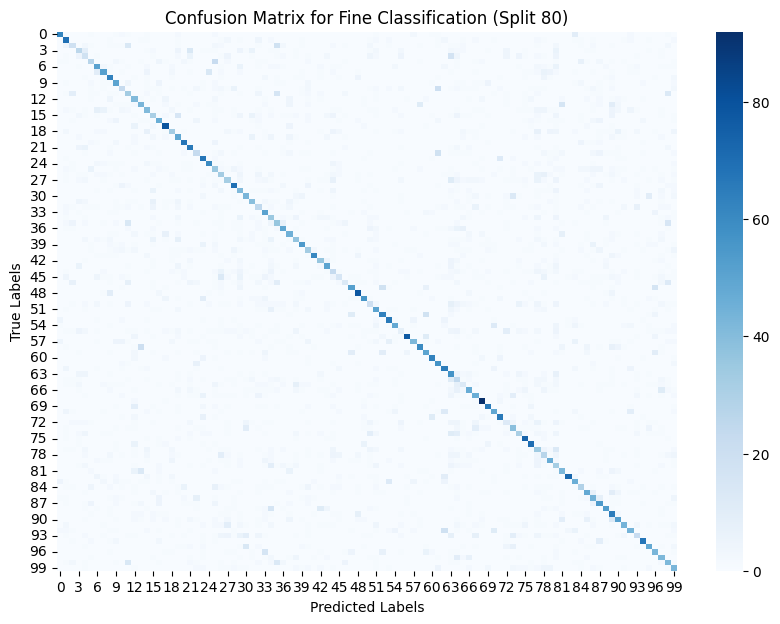

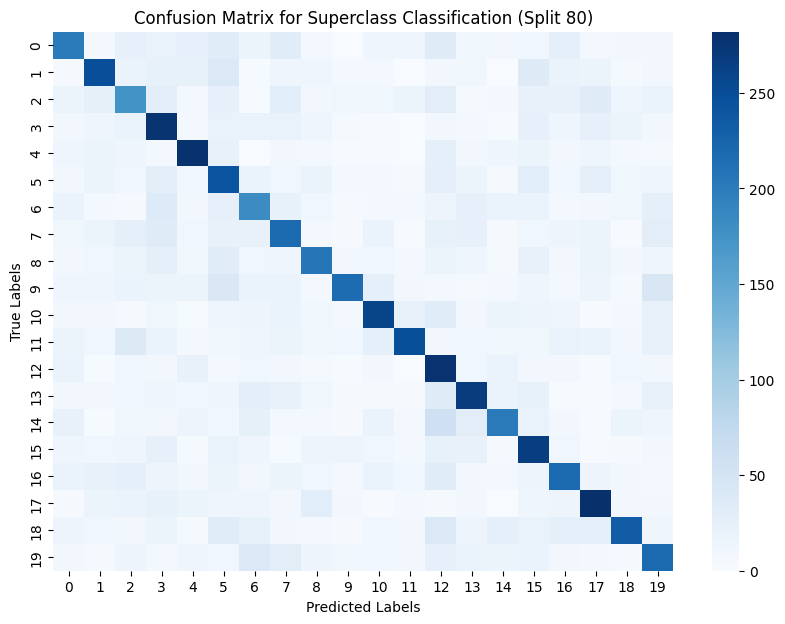

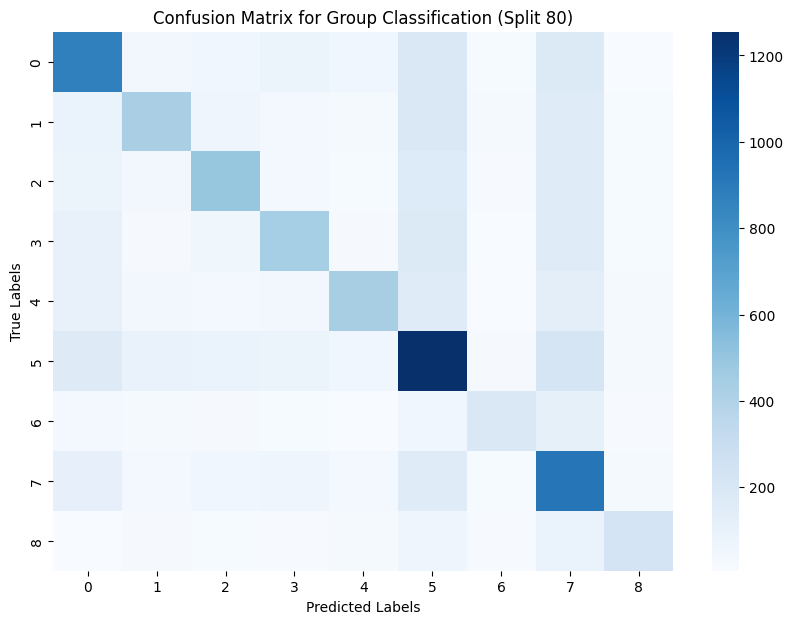


🔹 Training with 90:9 split 🔹


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 2.7374, Val Loss: 2.5858
✔ Model saved at epoch 1 for split 90
Epoch 2/30 - Train Loss: 2.4805, Val Loss: 2.4235
✔ Model saved at epoch 2 for split 90
Epoch 3/30 - Train Loss: 2.3088, Val Loss: 2.2825
✔ Model saved at epoch 3 for split 90
Epoch 4/30 - Train Loss: 2.1792, Val Loss: 2.1886
✔ Model saved at epoch 4 for split 90
Epoch 5/30 - Train Loss: 2.0809, Val Loss: 2.1950
Epoch 6/30 - Train Loss: 2.0030, Val Loss: 2.0934
✔ Model saved at epoch 6 for split 90
Epoch 7/30 - Train Loss: 1.9299, Val Loss: 1.9924
✔ Model saved at epoch 7 for split 90
Epoch 8/30 - Train Loss: 1.8785, Val Loss: 1.9580
✔ Model saved at epoch 8 for split 90
Epoch 9/30 - Train Loss: 1.8230, Val Loss: 1.9847
Epoch 10/30 - Train Loss: 1.7768, Val Loss: 1.8942
✔ Model saved at epoch 10 for split 90
Epoch 11/30 - Train Loss: 1.7400, Val Loss: 1.8647
✔ Model saved at epoch 11 for split 90
Epoch 12/30 - Train Loss: 1.6942, Val Loss: 1.8563
✔ Model saved at epoch 12 for split 90
Epoch 13/30 - 

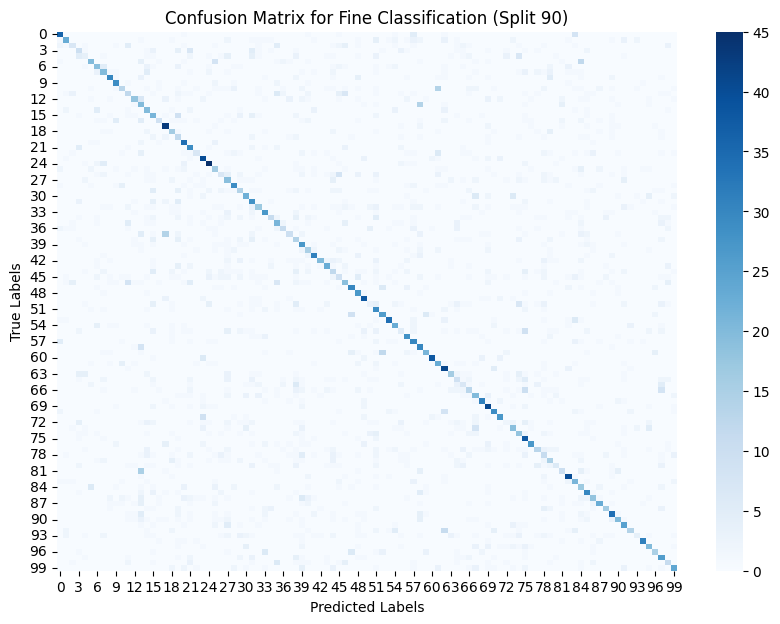

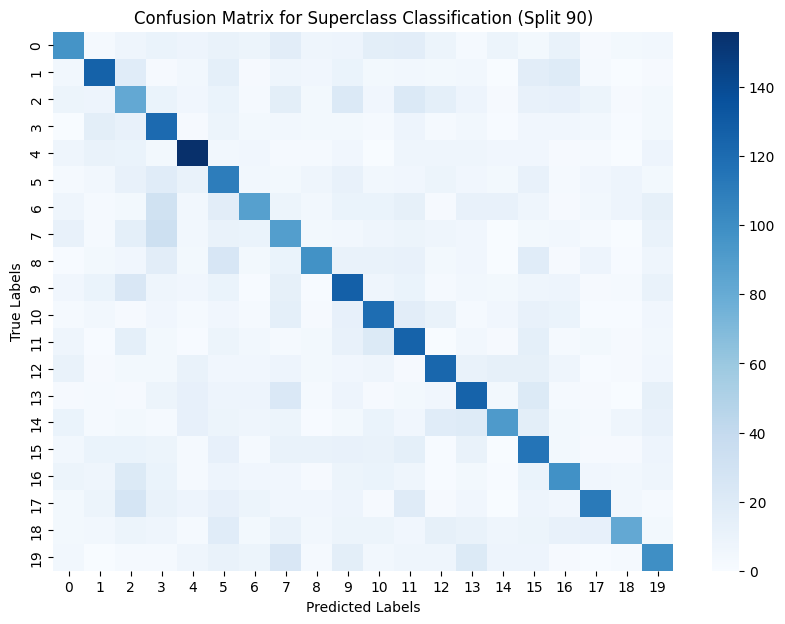

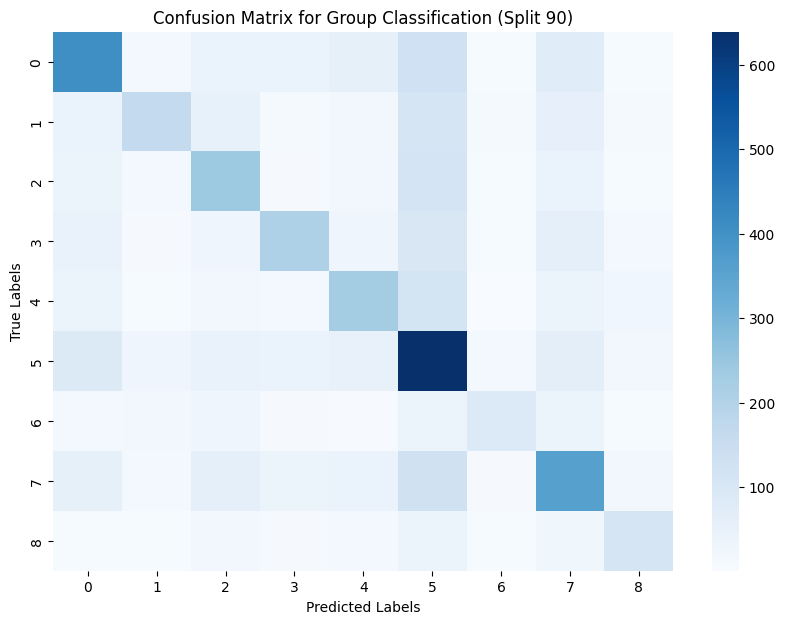

In [ ]:
# Iterate over different splits
for split in splits:
    print(f"\n🔹 Training with {int(split * 100)}:{int((1 - split) * 100)} split 🔹")

    # Split dataset
    train_size = int(split * len(full_trainset))
    val_size = len(full_trainset) - train_size
    train_data, val_data = random_split(full_trainset, [train_size, val_size])

    # Create DataLoaders
    trainloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    validloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # Define model
    model = CNN().to(device)

    # Define optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3, verbose=True, min_lr=1e-7)

    # Early stopping variables
    best_val_loss = float("inf")
    epochs_no_improve = 0
    checkpoint_path = f"model_checkpoints/best_model_{int(split*100)}.pth"

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for images, labels in trainloader:  # Loop through batches
            fine_labels = labels
            coarse_labels = torch.tensor([fine_to_superclass[label.item()] for label in labels]).to(device)
            group_labels = torch.tensor([superclass_to_group[coarse_label.item()] for coarse_label in coarse_labels]).to(device)
            images, fine_labels = images.to(device), fine_labels.to(device)

            optimizer.zero_grad()
            fine_out, coarse_out, group_out = model(images)

            loss_fine = criterion(fine_out, fine_labels)
            loss_coarse = criterion(coarse_out, coarse_labels)
            loss_group = criterion(group_out, group_labels)
            weight_fine = 1 / np.log(100)  # ≈ 0.217
            weight_super = 1 / np.log(20)  # ≈ 0.386
            weight_group = 1 / np.log(9)   # ≈ 0.480

            total_loss = (weight_fine * loss_fine) + (weight_super * loss_coarse) + (weight_group * loss_group)


            total_loss.backward()
            optimizer.step()
            train_loss += total_loss.item()

        # Validation loop
        model.eval()
        val_loss = 0.0
        all_fine_labels, all_coarse_labels, all_group_labels = [], [], []
        all_fine_preds, all_coarse_preds, all_group_preds = [], [], []

        with torch.no_grad():
            for images, labels in validloader:
                fine_labels = labels
                weight_fine = 1 / np.log(100)  # ≈ 0.217
                weight_super = 1 / np.log(20)  # ≈ 0.386
                weight_group = 1 / np.log(9)   # ≈ 0.480

                coarse_labels = torch.tensor([fine_to_superclass[label.item()] for label in labels]).to(device)
                group_labels = torch.tensor([superclass_to_group[coarse_label.item()] for coarse_label in coarse_labels]).to(device)
                images, fine_labels = images.to(device), fine_labels.to(device)

                fine_out, coarse_out, group_out = model(images)

                loss_fine = criterion(fine_out, fine_labels)
                loss_coarse = criterion(coarse_out, coarse_labels)
                loss_group = criterion(group_out, group_labels)
                total_val_loss = (weight_fine * loss_fine) + (weight_super * loss_coarse) + (weight_group * loss_group)
                val_loss += total_val_loss.item()

                all_fine_labels.extend(fine_labels.cpu().numpy())
                all_coarse_labels.extend(coarse_labels.cpu().numpy())
                all_group_labels.extend(group_labels.cpu().numpy())

                all_fine_preds.extend(torch.argmax(fine_out, dim=1).cpu().numpy())
                all_coarse_preds.extend(torch.argmax(coarse_out, dim=1).cpu().numpy())
                all_group_preds.extend(torch.argmax(group_out, dim=1).cpu().numpy())

        # Average losses
        train_loss /= len(trainloader)
        val_loss /= len(validloader)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Reduce LR on Plateau
        scheduler.step(val_loss)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0  # Reset counter
            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✔ Model saved at epoch {epoch+1} for split {int(split*100)}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stopping_patience:
                print(f"⏹ Early stopping triggered at epoch {epoch+1} for split {int(split*100)}")
                break

    # Compute Confusion Matrices
    for labels, preds, name in zip(
        [all_fine_labels, all_coarse_labels, all_group_labels],
        [all_fine_preds, all_coarse_preds, all_group_preds],
        ["Fine", "Superclass", "Group"]
    ):
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
        plt.title(f'Confusion Matrix for {name} Classification (Split {int(split*100)})')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.show()

In [ ]:
# Function to Plot Loss vs Accuracy Curves
def plot_loss_accuracy(train_losses, val_losses, train_accs, val_accs, split):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {split} Split")
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train Accuracy", marker="o")
    plt.plot(val_accs, label="Validation Accuracy", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve - {split} Split")
    plt.legend()

    plt.show()

## Model Testing

In [ ]:
# Load the best model correctly

model = CNN().to(device)
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.to(device)
model.eval()
from torchsummary import summary
summary(model, (3, 32, 32))  # Assuming CIFAR-100 input size




----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 512]       1,049,088
           Linear-11                  [-1, 100]          51,300
           Linear-12                  [-1, 100]          10,100
           Linear-13                   [-1, 20]           2,020
           Linear-14                   

Total parameters

In [ ]:
def count_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params
    return total_params, trainable_params, non_trainable_params


total_params, trainable_params, non_trainable_params = count_parameters(model)

print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")
print(f"Non-trainable Parameters: {non_trainable_params}")


Total Parameters: 1207113
Trainable Parameters: 1207113
Non-trainable Parameters: 0


In [ ]:
from sklearn.metrics import accuracy_score

# Define splits and checkpoint paths
splits = [0.7, 0.8, 0.9]
checkpoint_paths = {split: f"model_checkpoints/best_model_{int(split*100)}.pth" for split in splits}

# Create DataLoader for testing
testloader = DataLoader(testset, batch_size=128, shuffle=False)

# Evaluate for each split
for split in splits:
    print(f"\n🔹 Evaluating model trained with {int(split * 100)}:{int((1 - split) * 100)} split 🔹")

    # Load the model
    model = CNN().to(device)
    model.load_state_dict(torch.load(checkpoint_paths[split], map_location=device))
    model.eval()

    # Lists to store predictions and ground truth
    all_fine_labels, all_coarse_labels, all_group_labels = [], [], []
    all_fine_preds, all_coarse_preds, all_group_preds = [], [], []

    with torch.no_grad():
        for images, labels in testloader:
            fine_labels = labels
            coarse_labels = torch.tensor([fine_to_superclass[label.item()] for label in labels]).to(device)
            group_labels = torch.tensor([superclass_to_group[coarse_label.item()] for coarse_label in coarse_labels]).to(device)

            images, fine_labels = images.to(device), fine_labels.to(device)

            fine_out, coarse_out, group_out = model(images)

            all_fine_labels.extend(fine_labels.cpu().numpy())
            all_coarse_labels.extend(coarse_labels.cpu().numpy())
            all_group_labels.extend(group_labels.cpu().numpy())

            all_fine_preds.extend(torch.argmax(fine_out, dim=1).cpu().numpy())
            all_coarse_preds.extend(torch.argmax(coarse_out, dim=1).cpu().numpy())
            all_group_preds.extend(torch.argmax(group_out, dim=1).cpu().numpy())

    # Compute accuracy
    fine_acc = accuracy_score(all_fine_labels, all_fine_preds) * 100
    coarse_acc = accuracy_score(all_coarse_labels, all_coarse_preds) * 100
    group_acc = accuracy_score(all_group_labels, all_group_preds) * 100

    print(f"✔ Fine Class Accuracy: {fine_acc:.2f}%")
    print(f"✔ Superclass Accuracy: {coarse_acc:.2f}%")
    print(f"✔ Group Accuracy: {group_acc:.2f}%")



🔹 Evaluating model trained with 70:30 split 🔹


<ipython-input-11-b99336e5f600>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_paths[split], map_location=device))


✔ Fine Class Accuracy: 37.72%
✔ Superclass Accuracy: 39.86%
✔ Group Accuracy: 45.64%

🔹 Evaluating model trained with 80:19 split 🔹


<ipython-input-11-b99336e5f600>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_paths[split], map_location=device))


✔ Fine Class Accuracy: 45.59%
✔ Superclass Accuracy: 47.37%
✔ Group Accuracy: 52.83%

🔹 Evaluating model trained with 90:9 split 🔹


<ipython-input-11-b99336e5f600>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_paths[split], map_location=device))


✔ Fine Class Accuracy: 41.72%
✔ Superclass Accuracy: 44.57%
✔ Group Accuracy: 49.28%


# Bonus Task

In [ ]:
# Define CNN Model (Single Head)
class SingleHeadCNN(nn.Module):
    def __init__(self):
        super(SingleHeadCNN, self).__init__()

        # Feature Extractor
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_common = nn.Linear(256 * 4 * 4, 512)

        # Single classification head (100 classes)
        self.classifier = nn.Linear(512, 100)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_common(x)
        class_out = self.classifier(x)
        return class_out


# Define Severity-Based Loss Function
def severity_loss(logits, labels):
    # Compute predicted class
    preds = logits.argmax(dim=1)

    # Get true class details
    true_superclass = torch.tensor([fine_to_superclass[l.item()] for l in labels], device=device)
    true_group = torch.tensor([superclass_to_group[fine_to_superclass[l.item()]] for l in labels], device=device)

    # Get predicted class details
    pred_superclass = torch.tensor([fine_to_superclass[p.item()] for p in preds], device=device)
    pred_group = torch.tensor([superclass_to_group[fine_to_superclass[p.item()]] for p in preds], device=device)

    # Calculate severity penalties
    severity = (preds != labels).float()  # Base penalty (misclassification)
    severity += (pred_superclass != true_superclass).float()  # Superclass mismatch (severity 1)
    severity += (pred_group != true_group).float() * 2  # Group mismatch (severity 2)

    # Logits-based loss (Softmax to probabilities)
    probs = torch.softmax(logits, dim=1)

    # Extract true class probabilities
    class_loss = -torch.log(probs[torch.arange(len(labels)), labels] + 1e-7)

    # Weighted loss with severity
    total_loss = class_loss + (0.1 * severity)

    return total_loss.mean()


In [ ]:
# Define Hyperparameters
num_epochs = 30
batch_size = 128
learning_rate = 0.001
early_stopping_patience = 5
splits = [0.9]  # Different train-validation splits


🔹 Training with 90:9 split 🔹


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 4.1280, Train Acc: 11.84%, Val Loss: 3.6715, Val Acc: 19.82%
✔ Model saved at epoch 1 for split 90
Epoch 2/30 - Train Loss: 3.3987, Train Acc: 23.65%, Val Loss: 3.2895, Val Acc: 26.60%
✔ Model saved at epoch 2 for split 90
Epoch 3/30 - Train Loss: 3.0963, Train Acc: 28.99%, Val Loss: 3.0060, Val Acc: 32.04%
✔ Model saved at epoch 3 for split 90
Epoch 4/30 - Train Loss: 2.8813, Train Acc: 33.20%, Val Loss: 2.9141, Val Acc: 32.48%
✔ Model saved at epoch 4 for split 90
Epoch 5/30 - Train Loss: 2.7328, Train Acc: 36.09%, Val Loss: 2.7998, Val Acc: 35.12%
✔ Model saved at epoch 5 for split 90
Epoch 6/30 - Train Loss: 2.6130, Train Acc: 38.51%, Val Loss: 2.6876, Val Acc: 37.04%
✔ Model saved at epoch 6 for split 90
Epoch 7/30 - Train Loss: 2.5214, Train Acc: 40.14%, Val Loss: 2.5973, Val Acc: 38.96%
✔ Model saved at epoch 7 for split 90
Epoch 8/30 - Train Loss: 2.4424, Train Acc: 41.86%, Val Loss: 2.5859, Val Acc: 39.06%
✔ Model saved at epoch 8 for split 90
Epoch 9/

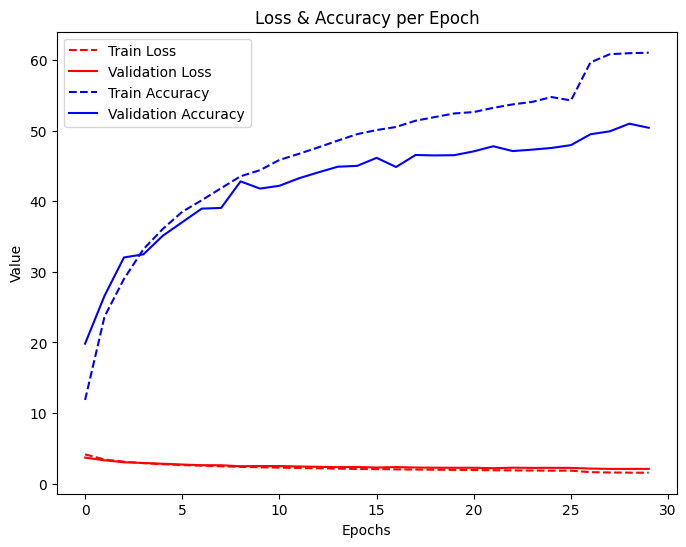

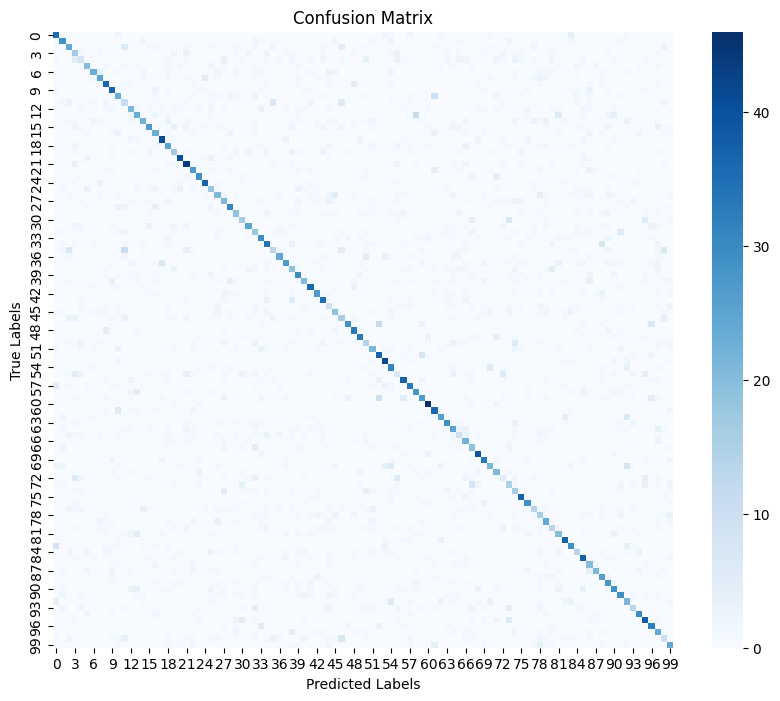

In [ ]:

    for split in splits:
        print(f"\n🔹 Training with {int(split * 100)}:{int((1 - split) * 100)} split 🔹")

        # Split dataset
        train_size = int(split * len(full_trainset))
        val_size = len(full_trainset) - train_size
        train_data, val_data = random_split(full_trainset, [train_size, val_size])

        # Create DataLoaders
        trainloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        validloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

        # Define Model
        model = SingleHeadCNN().to(device)

        # Define Optimizer & Scheduler
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3, verbose=True, min_lr=1e-7)

        # Early Stopping Variables
        best_val_loss = float("inf")
        epochs_no_improve = 0
        checkpoint_path = f"model_checkpoints/best_model_{int(split*100)}.pth"

        # Track loss and accuracy
        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        # Training Loop
        for epoch in range(num_epochs):
            model.train()
            train_loss, correct_train, total_train = 0.0, 0, 0

            for images, labels in trainloader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                logits = model(images)

                # Compute Severity-Aware Loss
                total_loss = severity_loss(logits, labels)
                total_loss.backward()
                optimizer.step()

                train_loss += total_loss.item()
                _, predicted = logits.max(1)
                correct_train += (predicted == labels).sum().item()
                total_train += labels.size(0)

            train_loss /= len(trainloader)
            train_accuracy = 100 * correct_train / total_train
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)

            # Validation Loop
            model.eval()
            val_loss, correct_val, total_val = 0.0, 0, 0
            all_preds, all_targets = [], []

            with torch.no_grad():
                for images, labels in validloader:
                    images, labels = images.to(device), labels.to(device)
                    logits = model(images)
                    total_val_loss = severity_loss(logits, labels)
                    val_loss += total_val_loss.item()

                    _, predicted = logits.max(1)
                    correct_val += (predicted == labels).sum().item()
                    total_val += labels.size(0)

                    all_preds.extend(predicted.cpu().numpy())
                    all_targets.extend(labels.cpu().numpy())

            val_loss /= len(validloader)
            val_accuracy = 100 * correct_val / total_val
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)

            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

            # Reduce LR on Plateau
            scheduler.step(val_loss)

            # Early Stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
                torch.save(model.state_dict(), checkpoint_path)
                print(f"✔ Model saved at epoch {epoch+1} for split {int(split*100)}")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience:
                    print(f"⏹ Early stopping triggered at epoch {epoch+1} for split {int(split*100)}")
                    break

        # Plot Loss vs Accuracy
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label="Train Loss", color='red', linestyle='--')
        plt.plot(val_losses, label="Validation Loss", color='red')
        plt.plot(train_accuracies, label="Train Accuracy", color='blue', linestyle='--')
        plt.plot(val_accuracies, label="Validation Accuracy", color='blue')
        plt.xlabel("Epochs")
        plt.ylabel("Value")
        plt.title("Loss & Accuracy per Epoch")
        plt.legend()
        plt.show()

        # Plot Confusion Matrix Heatmap
        cm = confusion_matrix(all_targets, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title('Confusion Matrix')
        plt.show()

Total Parameters

In [ ]:
model = SingleHeadCNN().to(device)
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.to(device)
model.eval()
from torchsummary import summary
summary(model, (3, 32, 32))  # Assuming CIFAR-100 input size




----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
           Linear-10                  [-1, 512]       2,097,664
           Linear-11                  [-1, 100]          51,300
Total params: 2,519,780
Trainable params: 2,519,780
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forw